In [5]:
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv

load_dotenv()

if os.getenv("OPENAI_API_KEY") is None:
    raise ValueError("OPENAI_API_KEY environment variable is not set")
else:
    print("OPENAI_API_KEY environment variable is set")

OPENAI_API_KEY environment variable is set


In [6]:
from langchain_core.messages import HumanMessage

llm = ChatOpenAI(
    model_name="gpt-5-nano",
    temperature=0.7
)

response = llm.invoke([HumanMessage(content="Hello, how are you?")])

print(response.content)

Hi there! I’m here and ready to help. How can I assist you today? If you’re not sure, tell me what you’re working on or what you’d like to do (write something, solve a problem, learn something new, plan something, etc.), and I’ll jump in.


In [10]:
from langchain_core.messages import AIMessage
from typing import List, Annotated
from typing import TypedDict
from operator import add

class Graph_Schema(TypedDict):
    messages_manual: List
    messages_auto: Annotated[List, add]


In [21]:
from langchain_core.messages import AIMessage

def create_post(state: Graph_Schema) -> Graph_Schema:

    messages_manual = state["messages_manual"]

    response_manual = llm.invoke(messages_manual).content
    response_manual_ai = AIMessage(content=response_manual)
    state["messages_manual"] = messages_manual + [response_manual_ai]

    messages_auto = state["messages_auto"]
    response_auto = llm.invoke(messages_auto).content
    response_auto_ai = AIMessage(content=response_auto)
    state["messages_auto"] = [response_auto_ai]

    return state

def curate_post(state: Graph_Schema) -> Graph_Schema:

    messages_manual = state["messages_manual"]

    response_manual = llm.invoke(messages_manual).content
    response_manual_ai = AIMessage(content=response_manual)
    state["messages_manual"] = messages_manual + [response_manual_ai]


    messages_auto = state["messages_auto"]
    response_auto = llm.invoke(messages_auto).content
    response_auto_ai = AIMessage(content=response_auto)
    state["messages_auto"] = [response_auto_ai]

    return state
    


In [22]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(Graph_Schema)

graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

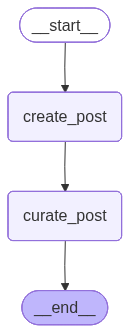

In [23]:
from IPython.display import Image, display

first_compiled_graph = graph.compile()

Image(first_compiled_graph.get_graph().draw_mermaid_png())

In [25]:
first_compiled_graph.invoke({"messages_manual": [HumanMessage(content="Create a post about the importance of data privacy in digital age")], "messages_auto": [HumanMessage(content="Curate the post")]})

{'messages_manual': [HumanMessage(content='Create a post about the importance of data privacy in digital age', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Here’s a ready-to-publish post you can use:\n\nData privacy isn’t a luxury—it’s a foundation for freedom, trust, and security in the digital age. Every click, search, and share leaves a footprint, and who controls that footprint matters. When data is collected, we gain convenience and personalization, but we also hand over power—power to shape ads, content, and even decisions about what’s kept or used. Privacy is about consent, transparency, and real control over your information: you should decide what you share, with whom, and for how long.\n\nSmall, practical steps matter: tighten privacy settings, enable two-factor authentication, use strong, unique passwords, review app permissions, and limit data sharing. Seek services that minimize data collection and offer clear privacy policies. Support stronger protect

In [20]:
# Using pretty printing
import pprint

pprint.pprint(first_compiled_graph.invoke({"messages_manual": [HumanMessage(content="Create a post about the importance of data privacy in digital age")]}))

{'messages_auto': [],
 'messages_manual': [HumanMessage(content='Create a post about the importance of data privacy in digital age', additional_kwargs={}, response_metadata={}),
                     AIMessage(content='Data privacy in the digital age isn’t a luxury — it’s a cornerstone of freedom, safety, and trustworthy innovation. Every app you use, every site you visit, and every smart device you own collects data about you. When privacy is protected, you move through the online world with confidence. When it’s ignored, you risk identity theft, unfair profiling, and a chilling effect that makes you censor what you share.\n\nWhy it matters:\n- Personal safety: Protects you from scams, fraud, and misuse of sensitive information.\n- Autonomy and fairness: Prevents decisions about you being made behind your back.\n- Trust and innovation: People share data willingly when they trust how it’s used.\n\nWhat you can do:\n- Review app permissions and data sharing settings.\n- Use strong, uniqu